# Model training

Let's see some ways we can use the normal equation (OLS estimation) to compute the linear model that interpolates better the training data.
First, we generate some random data:

# Linear Regression

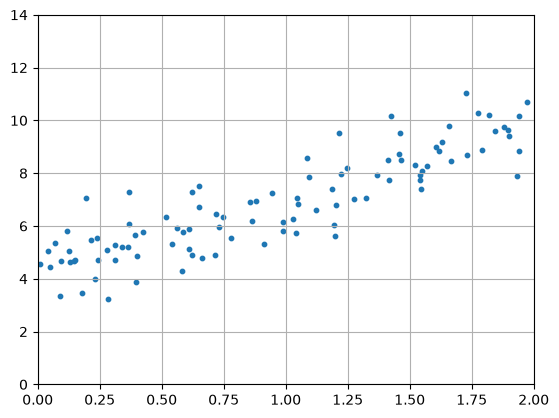

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3*X + np.random.randn(m, 1)

plt.scatter(x=X, y=y, s=10)
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 14.0)
plt.grid()
plt.show()

Now we can derive the OLS estimator using linear algebra from the normal equation. Remember. Since the model is $\hat{y}=\beta_0 + \beta_1 \cdot \textbf{X} + \epsilon$ the $\beta_0$ parameter must be multiplied by 1, in the full matrix form, so we must add a 1 to the $X$ matrix

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # adds x0 = 1b
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f"OLS estimator value: {theta_best}")

OLS estimator value: [[4.21509616]
 [2.77011339]]


The actual paremeters were 4 and 3, so close enough. Now we can make predictions with this:

In [3]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print(f"Predicted value: {y_predict}")

Predicted value: [[4.21509616]
 [9.75532293]]


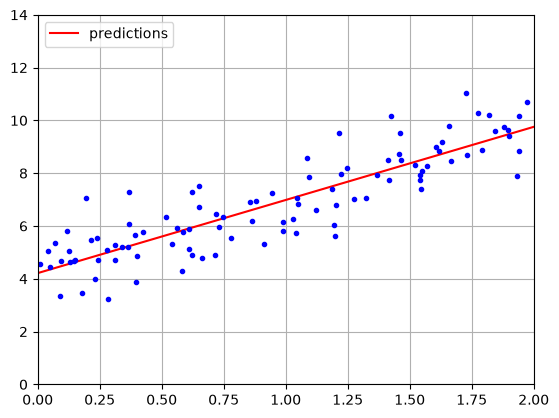

In [4]:
plt.plot(X_new, y_predict, "r-", label="predictions")
plt.plot(X, y, "b.")
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 14.0)
plt.grid()
plt.legend(loc="upper left")
plt.show()

You can also use scikit learn's `LinearRegression()` which does this for you. 

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [6]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

Same values! Notice that this algorithm of *least squares* is what happens under the hood. You can get it from numpy (which basically computes the **SVD** or the Moore-Penrose inverse $\textbf{X}^+$)

In [7]:
best_svd, residuals, rank, s = np.linalg.lstsq(X, y, rcond=1e-6)
print(f"solution: {best_svd}")
print(f"residuals: {residuals}")
print(f"rank: {rank}")
print(f"singular values: {s}")

solution: [[5.98027553]]
residuals: [584.94552486]
rank: 1
singular values: [11.1118834]


Or compute the pseudoinverse with numpy:

In [8]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

We can implement the same thing with **Batch Gradient Descent**:

In [9]:
eta = 0.1
epochs = 1000
m = len(X_b)
theta = np.random.rand(2, 1)

for epoch in range(epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

theta

array([[4.21509616],
       [2.77011339]])

Or with **Stochastic Gradient Descent**:

In [29]:
epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2, 1)

for epoch in range(epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # for SGD do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[4.22041137],
       [2.7494351 ]])

Or with sklearn:

In [34]:
from sklearn.linear_model import SGDRegressor

sdg_reg = SGDRegressor(max_iter=1000, n_iter_no_change=100, eta0=0.01, 
                       penalty=None, tol=1e-5)
sdg_reg.fit(X, y.ravel())
sdg_reg.intercept_, sdg_reg.coef_

(array([4.21415539]), array([2.7707421]))

# Polynomial Regression

What if the data is more complex than a straight line? You could add powers of each feature as a new feature, then train a linear model on this extended set of features.
First, we generate some non-linear data:

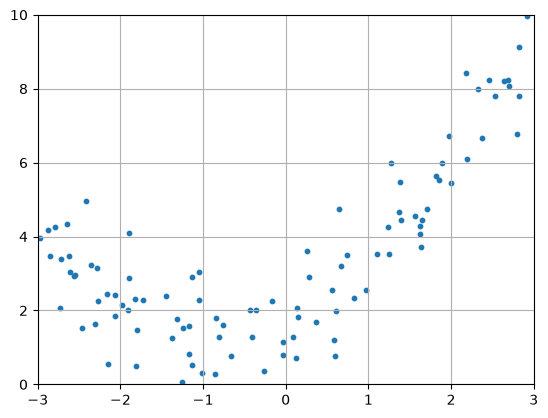

In [37]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
plt.scatter(x=X, y=y, s=10)
plt.xlim(-3.0, 3.0)
plt.ylim(0.0, 10.0)
plt.grid()
plt.show()